# Trust Wallet — Gas Pattern Analysis
Analyse statistique des transactions Ethereum pour identifier les patterns de fingerprinting.

In [19]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

DB_PATH = 'gas.db'
WALLET = 'Trust Wallet'

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query(
    "SELECT * FROM transactions WHERE wallet = ?",
    conn, params=(WALLET,)
)
conn.close()

print(f"Transactions chargées : {len(df):,}")
df.dtypes

Transactions chargées : 10,936


hash                     str
block                  int64
from_addr                str
wallet                   str
max_fee_gwei         float64
max_priority_gwei    float64
base_fee_gwei        float64
fee_factor           float64
fee_factor_parent    float64
gas_limit              int64
estimated_gas        float64
gas_limit_factor     float64
tx_type              float64
dtype: object

## 1. Vue d'ensemble — valeurs manquantes et statistiques de base

In [20]:
numeric_cols = ['max_fee_gwei', 'max_priority_gwei', 'base_fee_gwei',
                'fee_factor', 'fee_factor_parent', 'gas_limit', 'estimated_gas', 'gas_limit_factor']

# Taux de valeurs manquantes
null_pct = df[numeric_cols].isnull().mean() * 100
print("=== Valeurs manquantes (%) ===")
print(null_pct.round(2).to_string())
print()
print("=== Statistiques de base ===")
df[numeric_cols].describe().round(4)

=== Valeurs manquantes (%) ===
max_fee_gwei         13.53
max_priority_gwei    13.53
base_fee_gwei         0.00
fee_factor           13.53
fee_factor_parent    13.53
gas_limit             0.00
estimated_gas         1.30
gas_limit_factor      1.30

=== Statistiques de base ===


,max_fee_gwei,max_priority_gwei,base_fee_gwei,fee_factor,fee_factor_parent,gas_limit,estimated_gas,gas_limit_factor
count,9456.0000,9456.0000,10936.0000,9456.0000,9456.0000,1.093600e+04,1.079400e+04,10794.0000
mean,1.0233,0.9686,0.0487,1.1855,1.1753,1.296670e+05,9.184513e+04,1.3406
std,0.6980,0.6425,0.0520,2.5707,2.5287,2.146313e+05,1.571462e+05,0.2399
min,0.0271,0.0000,0.0201,0.0000,0.0000,2.100000e+04,2.100000e+04,0.6643
25%,1.0421,1.0000,0.0357,1.0667,1.0693,5.036150e+04,3.467925e+04,1.1000
50%,1.0486,1.0000,0.0401,1.2011,1.2000,7.381900e+04,4.921300e+04,1.5000
75%,1.0576,1.0000,0.0469,1.2962,1.2717,9.604600e+04,6.403100e+04,1.5000
max,40.0000,35.0000,1.0551,118.1078,116.0740,5.004928e+06,3.512059e+06,5.5634


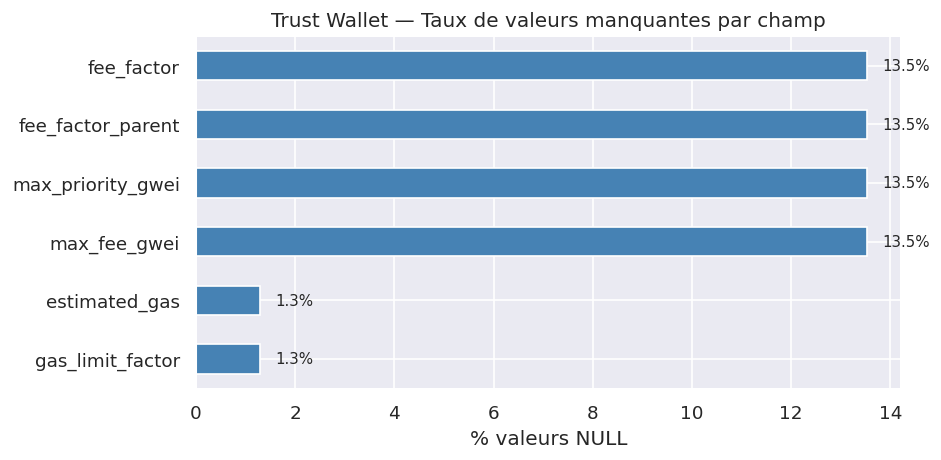

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
null_pct[null_pct > 0].sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('% valeurs NULL')
ax.set_title(f'{WALLET} — Taux de valeurs manquantes par champ')
for bar in ax.patches:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. gas_limit_factor — formule gasLimit = estimatedGas × factor

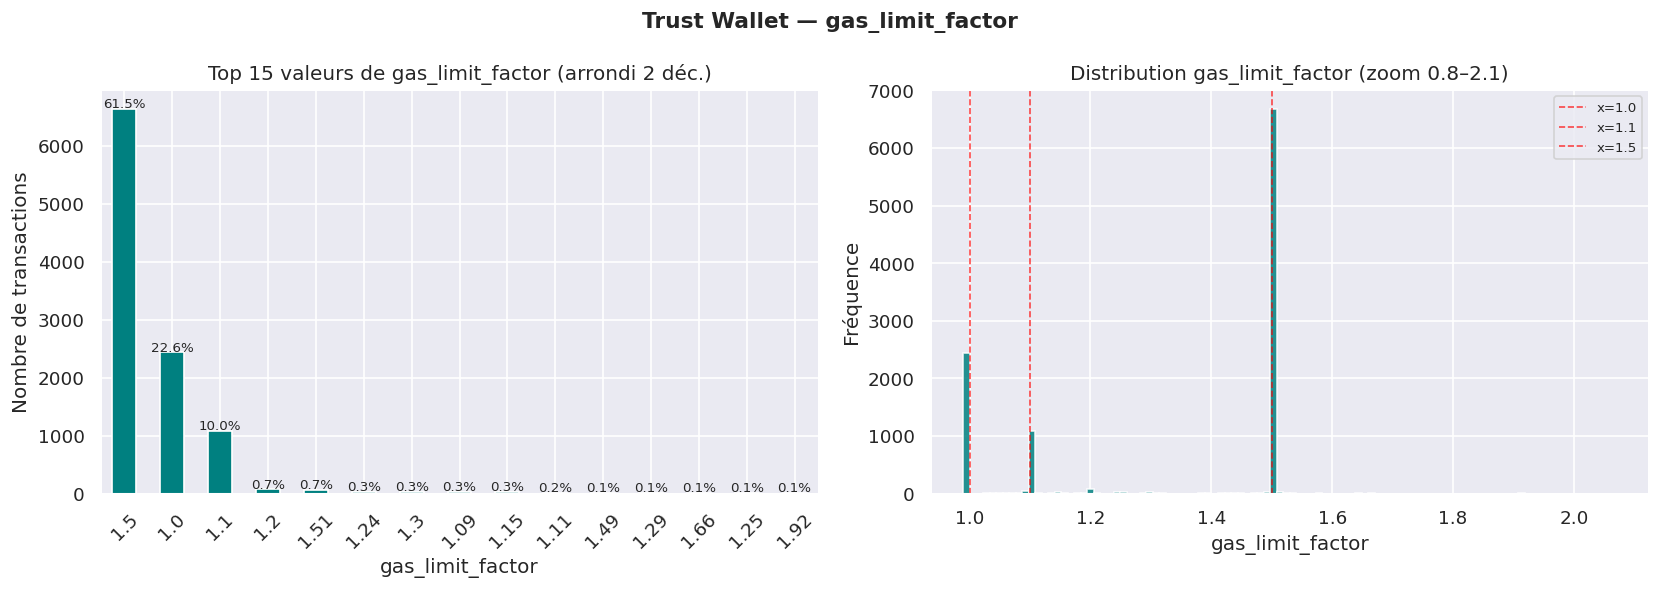


Transactions SANS estimated_gas (gas_limit_factor NULL) : 142 (1.3%)


In [22]:
df_glf = df[df['gas_limit_factor'].notna()].copy()
df_glf['glf_rounded'] = df_glf['gas_limit_factor'].round(2)

top_glf = df_glf['glf_rounded'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top valeurs
top_glf.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Top 15 valeurs de gas_limit_factor (arrondi 2 déc.)')
axes[0].set_xlabel('gas_limit_factor')
axes[0].set_ylabel('Nombre de transactions')
axes[0].tick_params(axis='x', rotation=45)
for bar in axes[0].patches:
    pct = bar.get_height() / len(df_glf) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{pct:.1f}%', ha='center', fontsize=8)

# Distribution continue (zoom 0.8 – 2.0)
zoom = df_glf[(df_glf['gas_limit_factor'] >= 0.8) & (df_glf['gas_limit_factor'] <= 2.1)]
axes[1].hist(zoom['gas_limit_factor'], bins=100, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution gas_limit_factor (zoom 0.8–2.1)')
axes[1].set_xlabel('gas_limit_factor')
axes[1].set_ylabel('Fréquence')
for v in [1.0, 1.1, 1.5]:
    axes[1].axvline(v, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'x={v}')
axes[1].legend(fontsize=8)

plt.suptitle(f'{WALLET} — gas_limit_factor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTransactions SANS estimated_gas (gas_limit_factor NULL) : {df['gas_limit_factor'].isna().sum():,} ({df['gas_limit_factor'].isna().mean()*100:.1f}%)")

In [23]:
# Cas gas_limit_factor = 1.0 : gas_limit == estimated_gas exactement ?
exact = df_glf[df_glf['glf_rounded'] == 1.0].copy()
exact['diff'] = (exact['gas_limit'] - exact['estimated_gas']).abs()
print(f"gas_limit_factor ≈ 1.0 : {len(exact):,} txs")
print(f"  dont gas_limit == estimated_gas exactement : {(exact['diff']==0).sum():,}")
print(f"  diff max observée : {exact['diff'].max()}")
print()

# Cas gas_limit_factor = 1.5 : arrondi ?
half = df_glf[df_glf['glf_rounded'] == 1.5].copy()
half['glf_exact'] = half['gas_limit'] / half['estimated_gas']
print(f"gas_limit_factor ≈ 1.5 : {len(half):,} txs")
print(f"  distribution glf exact (std) : {half['glf_exact'].std():.6f}")
print(f"  valeur médiane exacte : {half['glf_exact'].median():.6f}")
print(f"  exemples : {half['glf_exact'].head(5).values}")

gas_limit_factor ≈ 1.0 : 2,436 txs
  dont gas_limit == estimated_gas exactement : 2,433
  diff max observée : 1634.0

gas_limit_factor ≈ 1.5 : 6,636 txs
  distribution glf exact (std) : 0.000287
  valeur médiane exacte : 1.499992
  exemples : [1.49999919 1.49999118 1.49998984 1.5        1.5       ]


## 3. max_priority_gwei — valeurs du tip

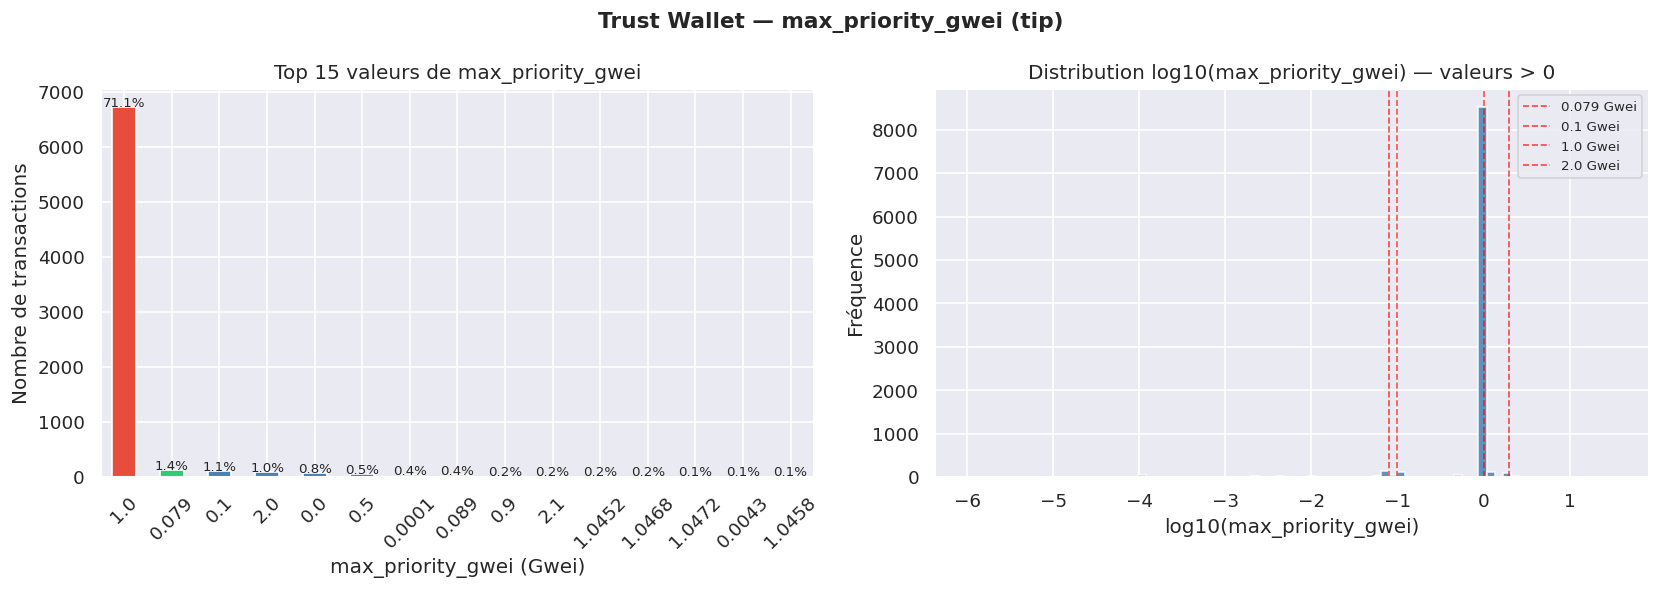

prio = 0.0 : 72 (0.8%)
prio = 1.0 : 6,723 (71.1%)
prio = 0.079 : 133


In [24]:
df_prio = df[df['max_priority_gwei'].notna()].copy()
df_prio['prio_rounded'] = df_prio['max_priority_gwei'].round(4)

top_prio = df_prio['prio_rounded'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top valeurs
colors = ['#e74c3c' if v == 1.0 else '#2ecc71' if v == 0.079 else 'steelblue' for v in top_prio.index]
top_prio.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Top 15 valeurs de max_priority_gwei')
axes[0].set_xlabel('max_priority_gwei (Gwei)')
axes[0].set_ylabel('Nombre de transactions')
axes[0].tick_params(axis='x', rotation=45)
for bar in axes[0].patches:
    pct = bar.get_height() / len(df_prio) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{pct:.1f}%', ha='center', fontsize=8)

# Distribution log-scale
nonzero_prio = df_prio[df_prio['max_priority_gwei'] > 0]['max_priority_gwei']
axes[1].hist(np.log10(nonzero_prio + 1e-9), bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution log10(max_priority_gwei) — valeurs > 0')
axes[1].set_xlabel('log10(max_priority_gwei)')
axes[1].set_ylabel('Fréquence')
for v in [0.079, 0.1, 1.0, 2.0]:
    axes[1].axvline(np.log10(v), color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'{v} Gwei')
axes[1].legend(fontsize=8)

plt.suptitle(f'{WALLET} — max_priority_gwei (tip)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Valeurs spéciales
print(f"prio = 0.0 : {(df_prio['max_priority_gwei']==0).sum():,} ({(df_prio['max_priority_gwei']==0).mean()*100:.1f}%)")
print(f"prio = 1.0 : {(df_prio['prio_rounded']==1.0).sum():,} ({(df_prio['prio_rounded']==1.0).mean()*100:.1f}%)")
print(f"prio = 0.079 : {(df_prio['prio_rounded']==0.079).sum():,}")

## 4. fee_factor — relation max_fee / base_fee

fee_factor = 0.0 : 1,929 txs (20.4%)
  max_fee_gwei moyen dans ce cas : 1.061035 Gwei
  base_fee_gwei moyen dans ce cas : 0.047973 Gwei
  → max_fee == max_priority ? 100.0% des cas



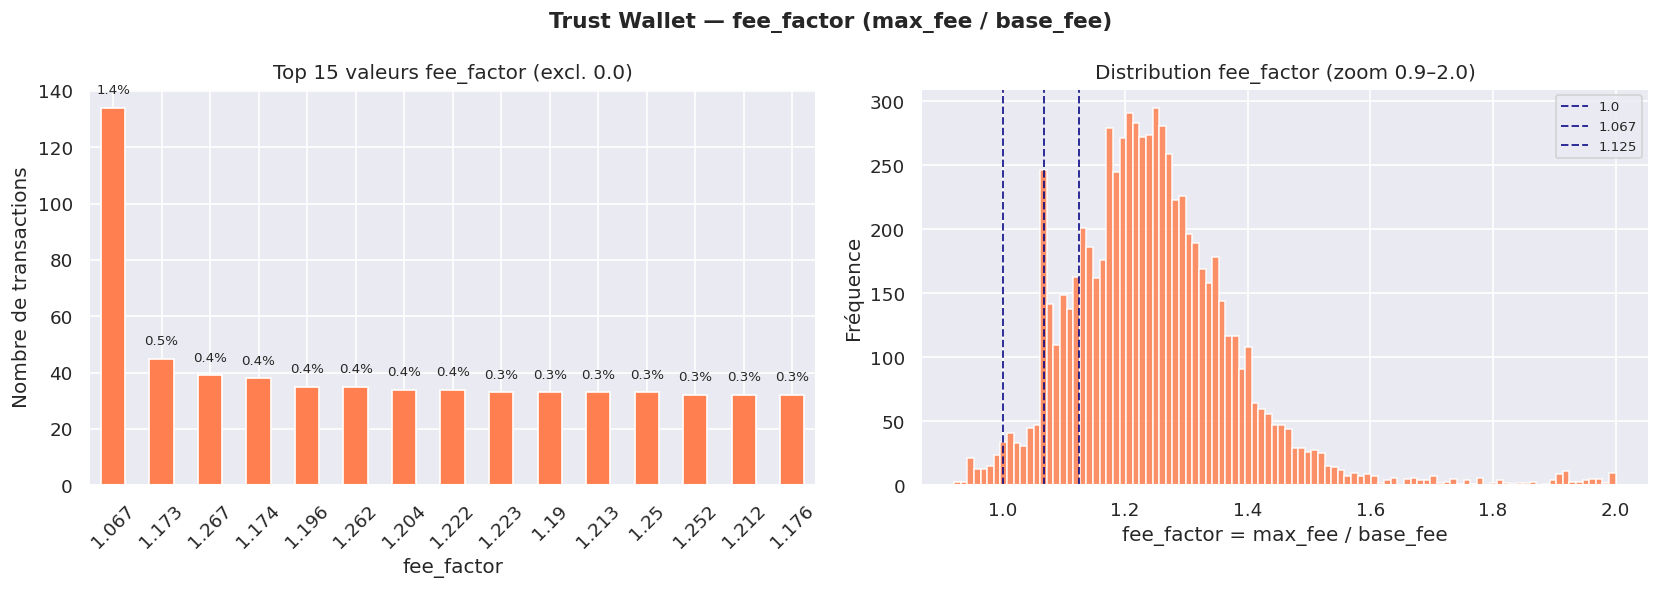

In [25]:
df_ff = df[df['fee_factor'].notna()].copy()
df_ff['ff_rounded'] = df_ff['fee_factor'].round(3)

# Cas spécial : fee_factor = 0.0 → max_fee ≤ base_fee
zero_ff = df_ff[df_ff['fee_factor'] == 0.0]
print(f"fee_factor = 0.0 : {len(zero_ff):,} txs ({len(zero_ff)/len(df_ff)*100:.1f}%)")
print(f"  max_fee_gwei moyen dans ce cas : {zero_ff['max_fee_gwei'].mean():.6f} Gwei")
print(f"  base_fee_gwei moyen dans ce cas : {zero_ff['base_fee_gwei'].mean():.6f} Gwei")
print(f"  → max_fee == max_priority ? {(zero_ff['max_fee_gwei'].round(6) == zero_ff['max_priority_gwei'].round(6)).mean()*100:.1f}% des cas")
print()

top_ff = df_ff[df_ff['fee_factor'] > 0]['ff_rounded'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_ff.plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Top 15 valeurs fee_factor (excl. 0.0)')
axes[0].set_xlabel('fee_factor')
axes[0].set_ylabel('Nombre de transactions')
axes[0].tick_params(axis='x', rotation=45)
for bar in axes[0].patches:
    pct = bar.get_height() / len(df_ff) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{pct:.1f}%', ha='center', fontsize=8)

# Distribution fee_factor entre 0.9 et 2.0
zoom_ff = df_ff[(df_ff['fee_factor'] > 0.9) & (df_ff['fee_factor'] <= 2.0)]
axes[1].hist(zoom_ff['fee_factor'], bins=100, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution fee_factor (zoom 0.9–2.0)')
axes[1].set_xlabel('fee_factor = max_fee / base_fee')
axes[1].set_ylabel('Fréquence')
for v in [1.0, 1.067, 1.125]:
    axes[1].axvline(v, color='navy', linestyle='--', linewidth=1.2, alpha=0.8, label=f'{v}')
axes[1].legend(fontsize=8)

plt.suptitle(f'{WALLET} — fee_factor (max_fee / base_fee)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. max_fee vs base_fee — scatter plot pour visualiser la formule

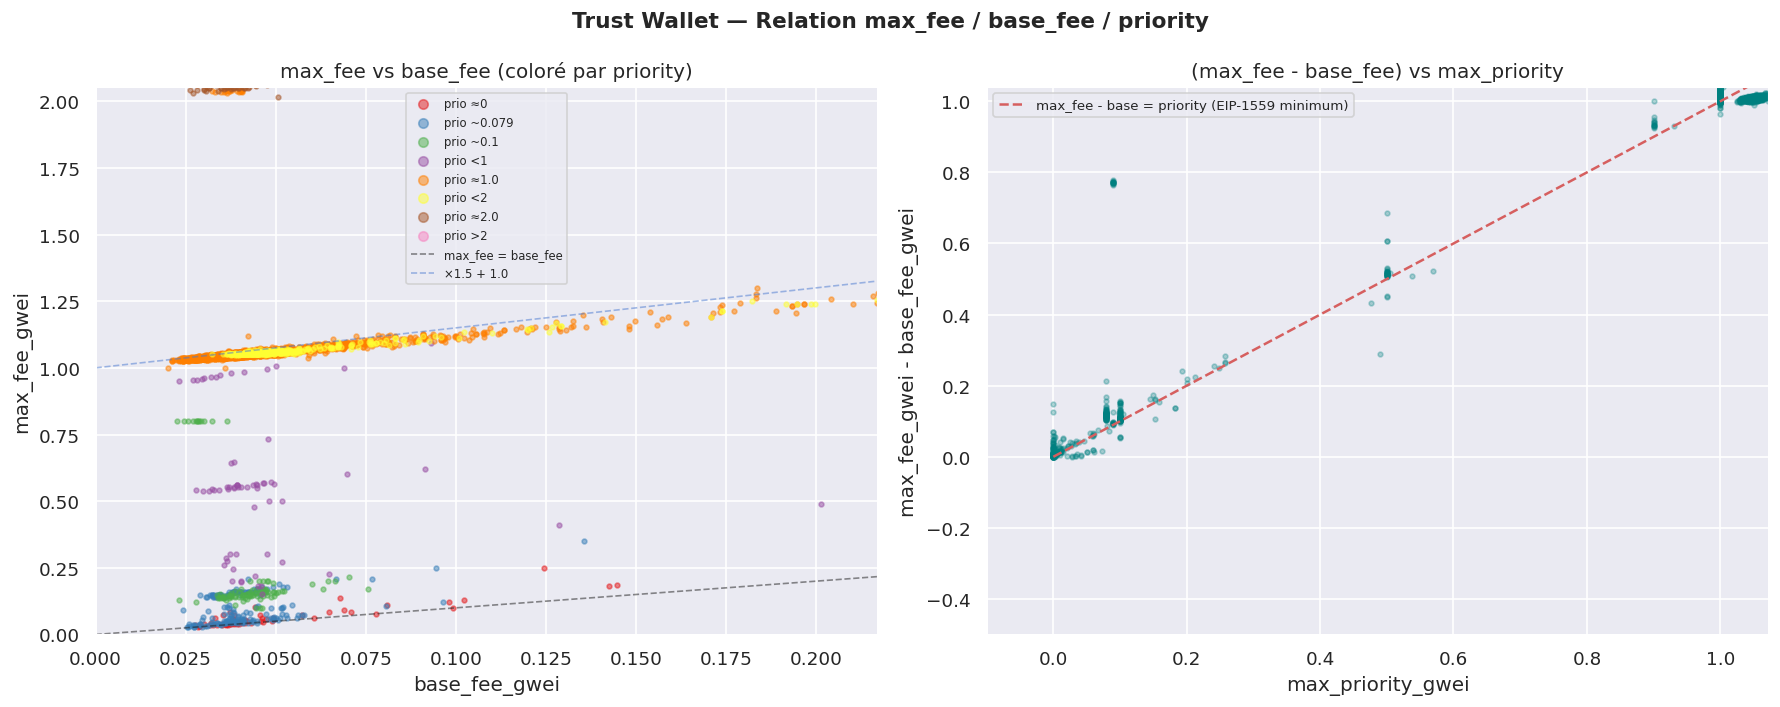

In [26]:
df_scatter = df[(df['base_fee_gwei'] > 0) & (df['max_fee_gwei'] > 0) & (df['max_priority_gwei'].notna())].copy()

# Segmenter par prio dominante
df_scatter['prio_label'] = pd.cut(
    df_scatter['max_priority_gwei'],
    bins=[-0.001, 0.0001, 0.08, 0.12, 0.95, 1.05, 1.9, 2.1, 999],
    labels=['≈0', '~0.079', '~0.1', '<1', '≈1.0', '<2', '≈2.0', '>2']
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter max_fee vs base_fee
sample = df_scatter.sample(min(5000, len(df_scatter)), random_state=42)
palette = sns.color_palette('Set1', n_colors=8)
for i, label in enumerate(['≈0', '~0.079', '~0.1', '<1', '≈1.0', '<2', '≈2.0', '>2']):
    mask = sample['prio_label'] == label
    if mask.sum() > 0:
        axes[0].scatter(sample[mask]['base_fee_gwei'], sample[mask]['max_fee_gwei'],
                        s=8, alpha=0.5, label=f'prio {label}', color=palette[i])

# Lignes de référence
x_range = np.linspace(0, df_scatter['base_fee_gwei'].quantile(0.99), 100)
axes[0].plot(x_range, x_range, 'k--', linewidth=1, label='max_fee = base_fee', alpha=0.5)
axes[0].plot(x_range, x_range * 1.5 + 1.0, 'b--', linewidth=1, label='×1.5 + 1.0', alpha=0.5)
axes[0].set_xlabel('base_fee_gwei')
axes[0].set_ylabel('max_fee_gwei')
axes[0].set_title('max_fee vs base_fee (coloré par priority)')
axes[0].legend(fontsize=7, markerscale=2)
axes[0].set_xlim(0, df_scatter['base_fee_gwei'].quantile(0.99))
axes[0].set_ylim(0, df_scatter['max_fee_gwei'].quantile(0.99))

# max_fee - base_fee vs max_priority
df_scatter['max_fee_minus_base'] = df_scatter['max_fee_gwei'] - df_scatter['base_fee_gwei']
sample2 = df_scatter.sample(min(5000, len(df_scatter)), random_state=42)
axes[1].scatter(sample2['max_priority_gwei'], sample2['max_fee_minus_base'],
                s=8, alpha=0.3, color='teal')
axes[1].plot([0, 5], [0, 5], 'r--', linewidth=1.5, label='max_fee - base = priority (EIP-1559 minimum)')
axes[1].set_xlabel('max_priority_gwei')
axes[1].set_ylabel('max_fee_gwei - base_fee_gwei')
axes[1].set_title('(max_fee - base_fee) vs max_priority')
axes[1].set_xlim(-0.1, df_scatter['max_priority_gwei'].quantile(0.97))
axes[1].set_ylim(-0.5, df_scatter['max_fee_minus_base'].quantile(0.97))
axes[1].legend(fontsize=8)

plt.suptitle(f'{WALLET} — Relation max_fee / base_fee / priority', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Heatmap — combinaison (gas_limit_factor × max_priority_gwei)

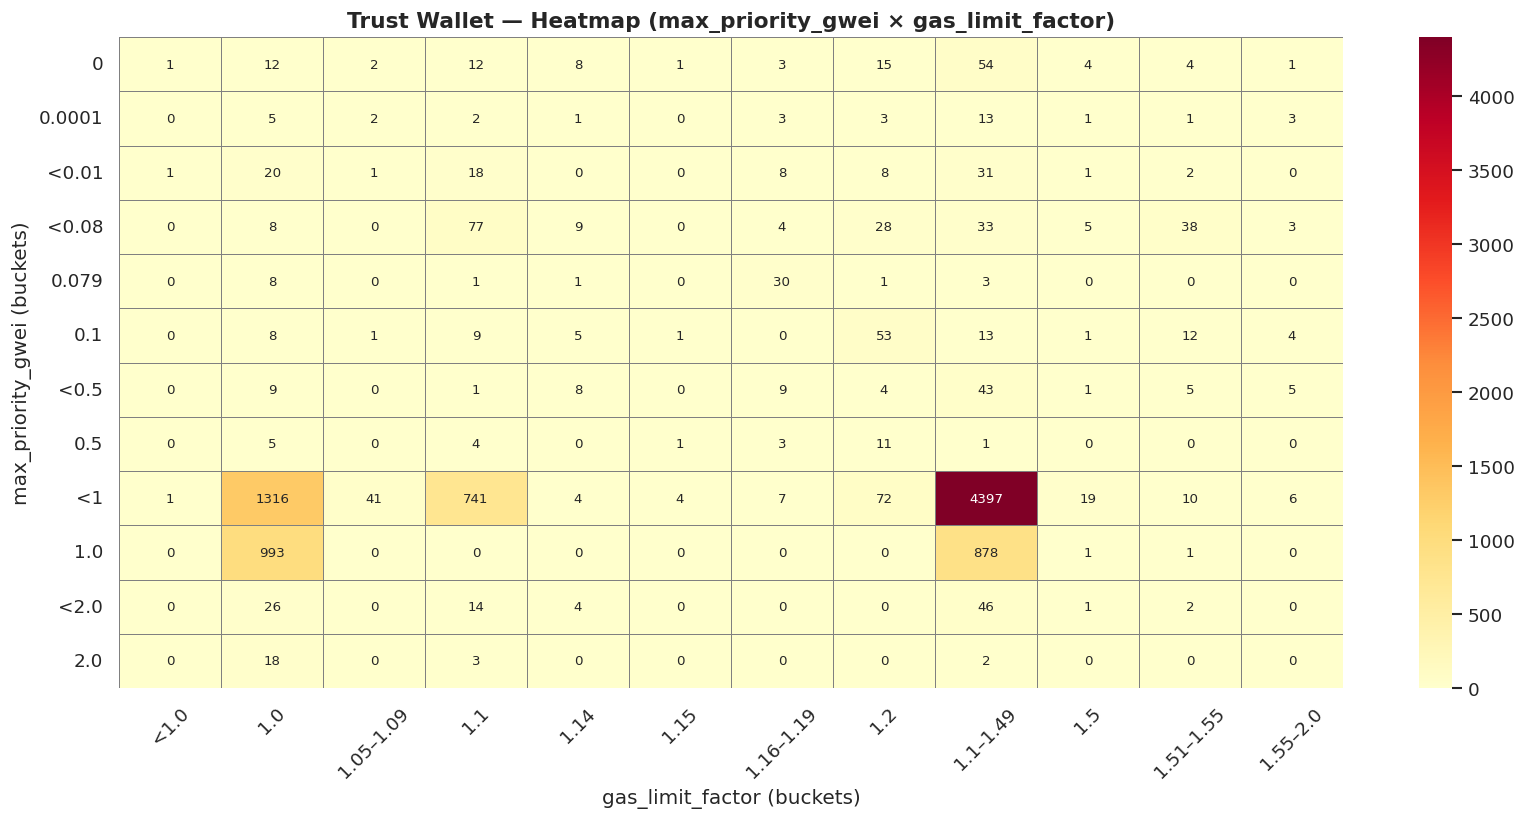

In [27]:
df_heat = df[df['gas_limit_factor'].notna() & df['max_priority_gwei'].notna()].copy()

# Buckets pour chaque dimension
glf_bins = [0, 0.99, 1.01, 1.09, 1.14, 1.16, 1.19, 1.21, 1.49, 1.51, 1.55, 1.99, 100]
glf_labels = ['<1.0', '1.0', '1.05–1.09', '1.1', '1.14', '1.15', '1.16–1.19', '1.2', '1.1–1.49', '1.5', '1.51–1.55', '1.55–2.0', '>2.0']

prio_bins = [-0.001, 0.0001, 0.001, 0.01, 0.08, 0.09, 0.11, 0.5, 0.99, 1.01, 1.9, 2.05, 999]
prio_labels = ['0', '0.0001', '<0.01', '<0.08', '0.079', '0.1', '<0.5', '0.5', '<1', '1.0', '<2.0', '2.0', '>2']

df_heat['glf_bin'] = pd.cut(df_heat['gas_limit_factor'], bins=glf_bins, labels=glf_labels[:len(glf_bins)-1])
df_heat['prio_bin'] = pd.cut(df_heat['max_priority_gwei'], bins=prio_bins, labels=prio_labels[:len(prio_bins)-1])

pivot = df_heat.groupby(['prio_bin', 'glf_bin'], observed=True).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.3, linecolor='gray',
            annot_kws={'size': 8})
ax.set_title(f'{WALLET} — Heatmap (max_priority_gwei × gas_limit_factor)', fontsize=13, fontweight='bold')
ax.set_xlabel('gas_limit_factor (buckets)')
ax.set_ylabel('max_priority_gwei (buckets)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 7. Segmentation des modes — clustering visuel

mode
Mode A: prio≈1.0, glf≈1.5        4425
Autre                            2651
Mode B: prio≈1.0, glf≈1.0        1329
Mode F: glf≈1.1 (x1.1 buffer)     884
Mode D: prio≈0.1, glf≈1.5          16
Mode C: prio≈0.079, glf≈1.5         9


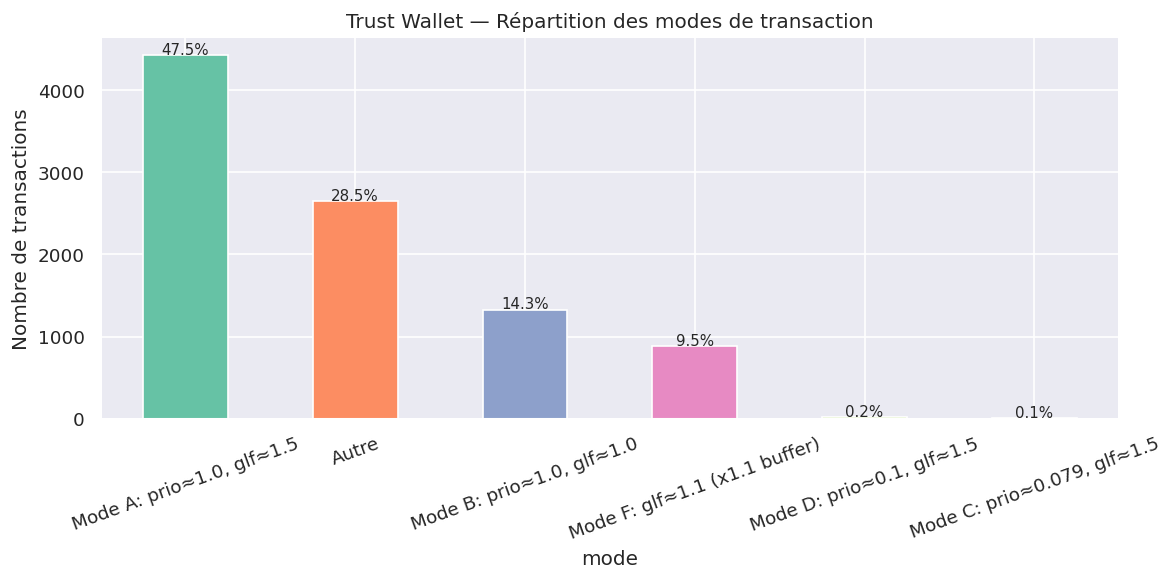

In [28]:
df_modes = df[
    df['gas_limit_factor'].notna() &
    df['max_priority_gwei'].notna() &
    df['fee_factor'].notna()
].copy()

# Définir les modes manuellement selon les patterns observés
def classify_mode(row):
    prio = row['max_priority_gwei']
    glf  = row['gas_limit_factor']
    ff   = row['fee_factor']
    if abs(prio - 1.0) < 0.02 and abs(glf - 1.5) < 0.05:
        return 'Mode A: prio≈1.0, glf≈1.5'
    elif abs(prio - 1.0) < 0.02 and abs(glf - 1.0) < 0.05:
        return 'Mode B: prio≈1.0, glf≈1.0'
    elif abs(prio - 0.079) < 0.005 and abs(glf - 1.5) < 0.05:
        return 'Mode C: prio≈0.079, glf≈1.5'
    elif abs(prio - 0.1) < 0.01 and abs(glf - 1.5) < 0.05:
        return 'Mode D: prio≈0.1, glf≈1.5'
    elif prio == 0.0 and ff == 0.0:
        return 'Mode E: prio=0, fee=0 (legacy?)'
    elif abs(glf - 1.1) < 0.02:
        return 'Mode F: glf≈1.1 (x1.1 buffer)'
    else:
        return 'Autre'

df_modes['mode'] = df_modes.apply(classify_mode, axis=1)
mode_counts = df_modes['mode'].value_counts()
print(mode_counts.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
mode_counts.plot(kind='bar', ax=ax, color=sns.color_palette('Set2', len(mode_counts)), edgecolor='white')
ax.set_title(f'{WALLET} — Répartition des modes de transaction')
ax.set_ylabel('Nombre de transactions')
ax.tick_params(axis='x', rotation=20)
for bar in ax.patches:
    pct = bar.get_height() / len(df_modes) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{pct:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

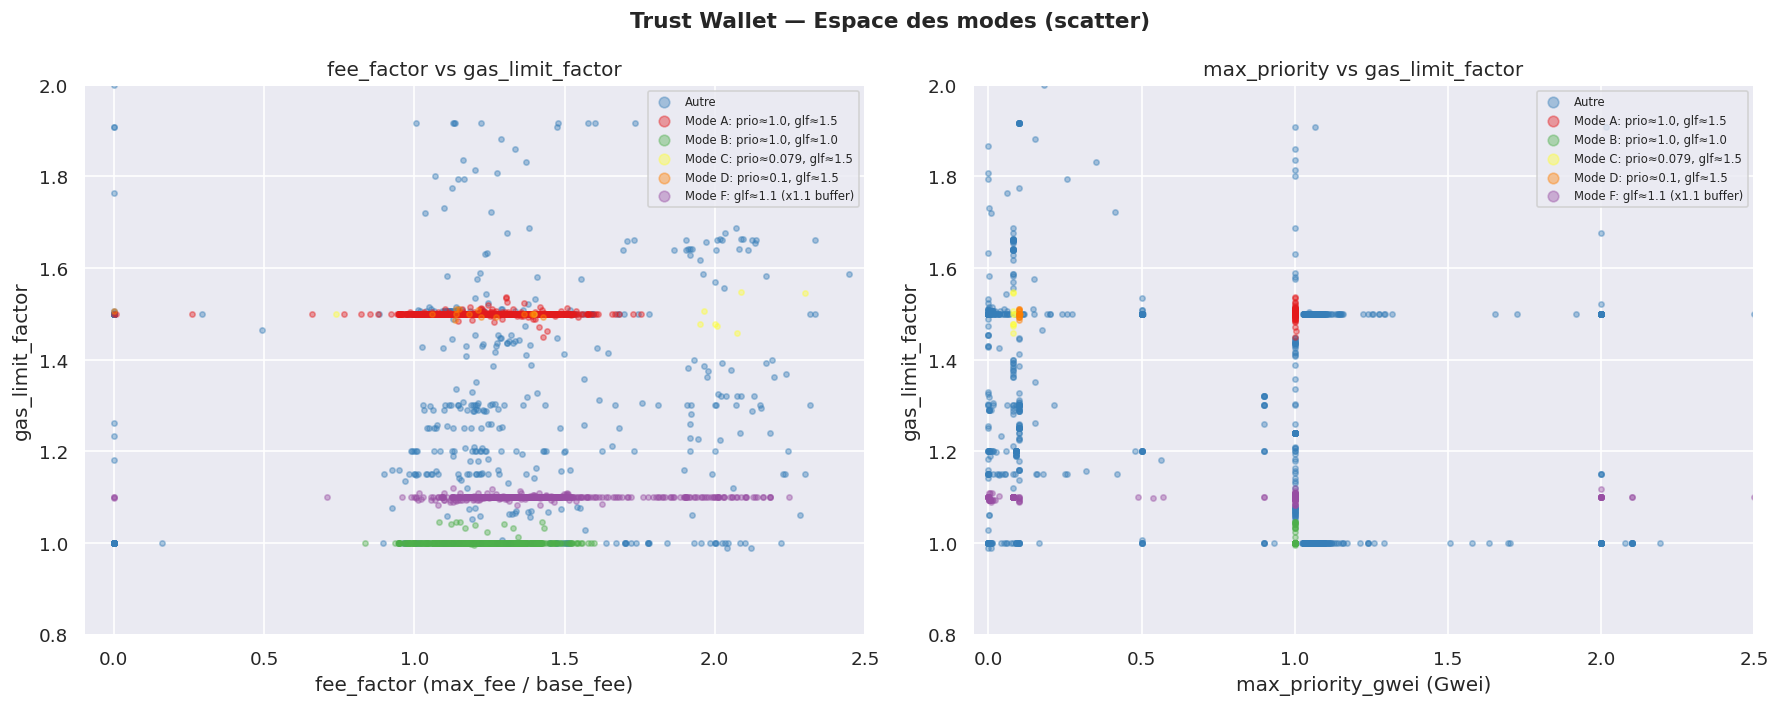

In [29]:
# Scatter 3D projeté : fee_factor vs gas_limit_factor, coloré par mode
sample_modes = df_modes.sample(min(8000, len(df_modes)), random_state=42)
palette_modes = dict(zip(df_modes['mode'].unique(), sns.color_palette('Set1', df_modes['mode'].nunique())))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for mode, grp in sample_modes.groupby('mode'):
    axes[0].scatter(grp['fee_factor'], grp['gas_limit_factor'],
                    s=10, alpha=0.4, label=mode, color=palette_modes.get(mode, 'gray'))
axes[0].set_xlabel('fee_factor (max_fee / base_fee)')
axes[0].set_ylabel('gas_limit_factor')
axes[0].set_title('fee_factor vs gas_limit_factor')
axes[0].set_xlim(-0.1, 2.5)
axes[0].set_ylim(0.8, 2.0)
axes[0].legend(fontsize=7, markerscale=2)

for mode, grp in sample_modes.groupby('mode'):
    axes[1].scatter(grp['max_priority_gwei'], grp['gas_limit_factor'],
                    s=10, alpha=0.4, label=mode, color=palette_modes.get(mode, 'gray'))
axes[1].set_xlabel('max_priority_gwei (Gwei)')
axes[1].set_ylabel('gas_limit_factor')
axes[1].set_title('max_priority vs gas_limit_factor')
axes[1].set_xlim(-0.05, 2.5)
axes[1].set_ylim(0.8, 2.0)
axes[1].legend(fontsize=7, markerscale=2)

plt.suptitle(f'{WALLET} — Espace des modes (scatter)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Évolution temporelle — patterns par block

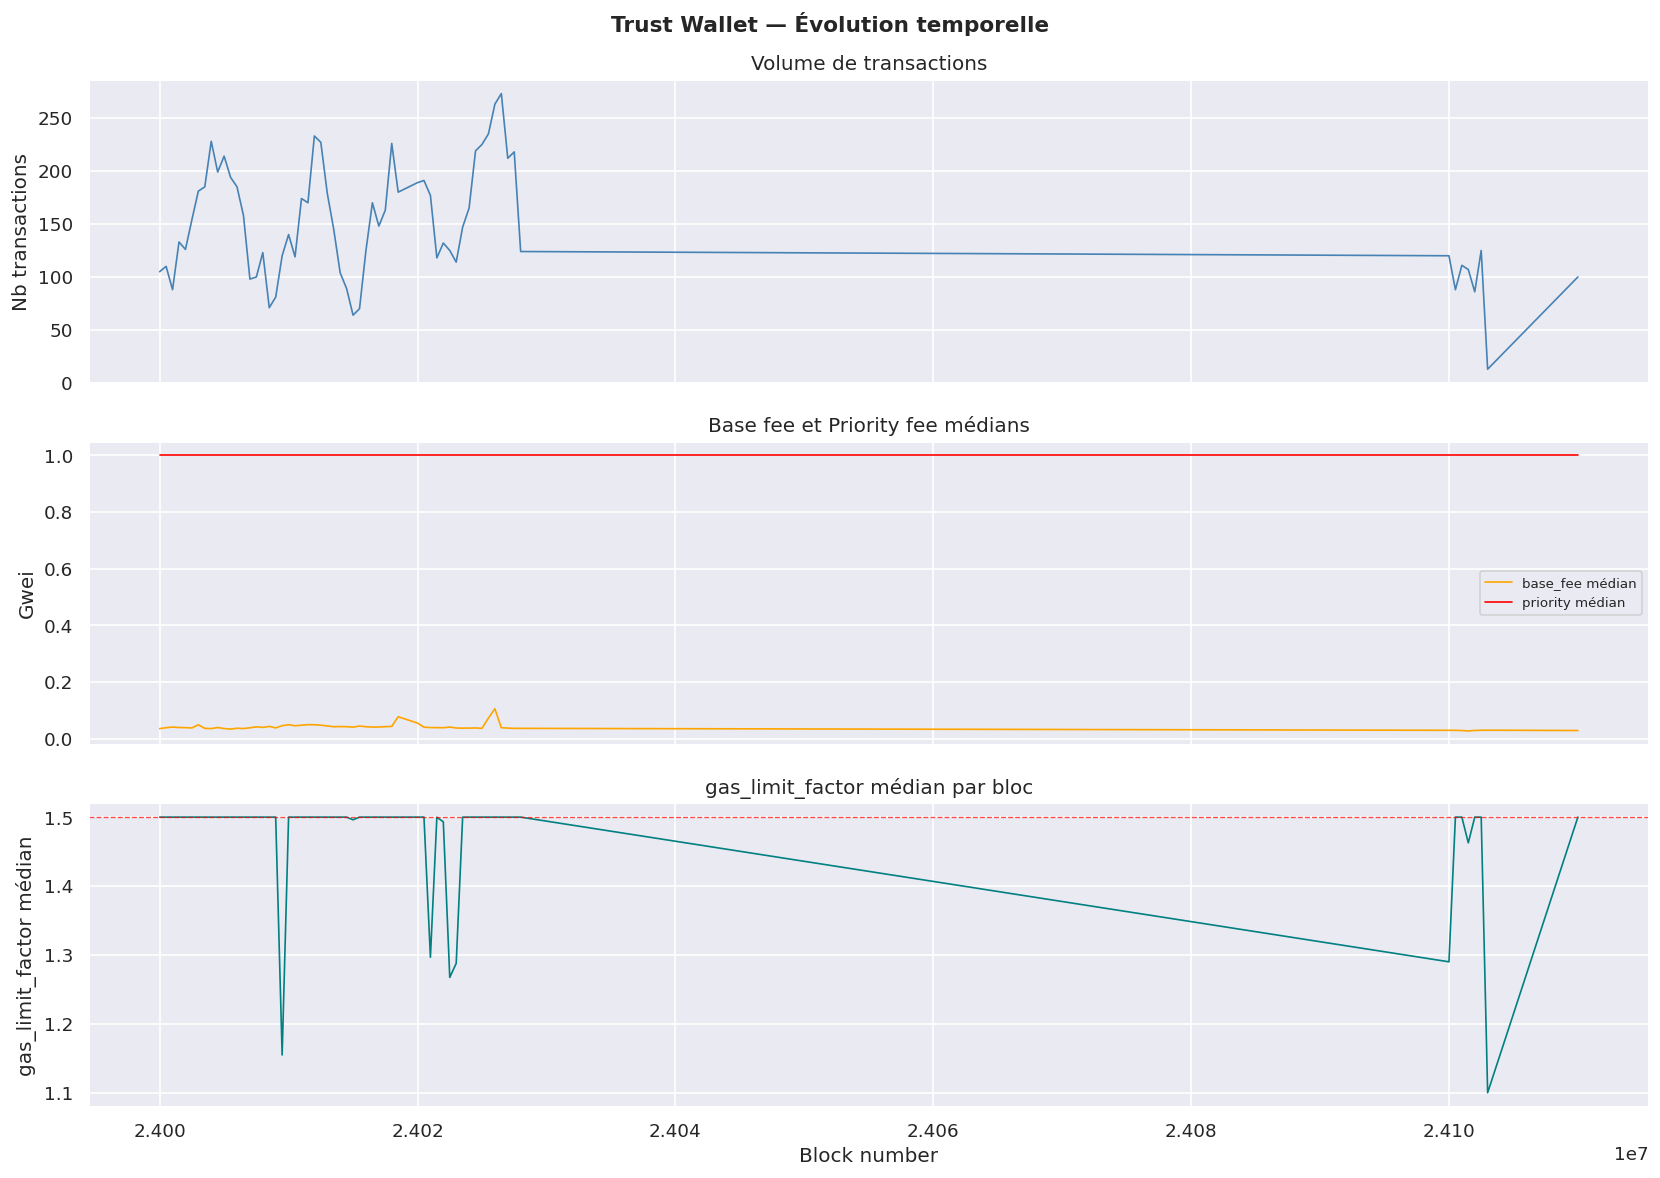

In [30]:
df_time = df[df['max_priority_gwei'].notna()].copy()
block_step = 500
df_time['block_bucket'] = (df_time['block'] // block_step) * block_step

block_stats = df_time.groupby('block_bucket').agg(
    n_txs=('hash', 'count'),
    avg_prio=('max_priority_gwei', 'median'),
    avg_basefee=('base_fee_gwei', 'median'),
    avg_glf=('gas_limit_factor', 'median')
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(block_stats['block_bucket'], block_stats['n_txs'], color='steelblue', linewidth=1)
axes[0].set_ylabel('Nb transactions')
axes[0].set_title('Volume de transactions')

axes[1].plot(block_stats['block_bucket'], block_stats['avg_basefee'], color='orange', linewidth=1, label='base_fee médian')
axes[1].plot(block_stats['block_bucket'], block_stats['avg_prio'], color='red', linewidth=1, label='priority médian')
axes[1].set_ylabel('Gwei')
axes[1].set_title('Base fee et Priority fee médians')
axes[1].legend(fontsize=8)

axes[2].plot(block_stats['block_bucket'], block_stats['avg_glf'], color='teal', linewidth=1)
axes[2].axhline(1.5, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
axes[2].set_ylabel('gas_limit_factor médian')
axes[2].set_title('gas_limit_factor médian par bloc')
axes[2].set_xlabel('Block number')

plt.suptitle(f'{WALLET} — Évolution temporelle', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Synthèse — signature fingerprint Trust Wallet

In [31]:
print("=" * 60)
print(f"  SYNTHÈSE FINGERPRINT — {WALLET}")
print("=" * 60)

total = len(df)

print(f"\nTotal transactions analysées : {total:,}")

# gas_limit_factor
glf_1_5 = (df['gas_limit_factor'].round(2) == 1.5).sum()
glf_1_0 = (df['gas_limit_factor'].round(2) == 1.0).sum()
glf_1_1 = (df['gas_limit_factor'].round(2) == 1.1).sum()
print(f"\n[gas_limit_factor]")
print(f"  × 1.5  → {glf_1_5:,} txs ({glf_1_5/total*100:.1f}%)")
print(f"  × 1.0  → {glf_1_0:,} txs ({glf_1_0/total*100:.1f}%)")
print(f"  × 1.1  → {glf_1_1:,} txs ({glf_1_1/total*100:.1f}%)")

# max_priority_gwei
df_p = df[df['max_priority_gwei'].notna()]
p1 = (df_p['max_priority_gwei'].round(4) == 1.0).sum()
p079 = (df_p['max_priority_gwei'].round(4) == 0.079).sum()
p01 = (df_p['max_priority_gwei'].round(4) == 0.1).sum()
p0 = (df_p['max_priority_gwei'] == 0.0).sum()
print(f"\n[max_priority_gwei]")
print(f"  1.0 Gwei (fixe)  → {p1:,} txs ({p1/total*100:.1f}%)")
print(f"  0.079 Gwei       → {p079:,} txs ({p079/total*100:.1f}%)")
print(f"  0.1 Gwei         → {p01:,} txs ({p01/total*100:.1f}%)")
print(f"  0.0 Gwei         → {p0:,} txs ({p0/total*100:.1f}%)")

# fee_factor
df_f = df[df['fee_factor'].notna()]
ff0 = (df_f['fee_factor'] == 0.0).sum()
print(f"\n[fee_factor = max_fee / base_fee]")
print(f"  0.0 (max_fee = max_priority sans basefee) → {ff0:,} txs ({ff0/total*100:.1f}%)")
print(f"  médiane fee_factor (hors 0.0) : {df_f[df_f['fee_factor']>0]['fee_factor'].median():.4f}")

# Combinaison principale
main_pattern = df[
    (df['max_priority_gwei'].round(4) == 1.0) &
    (df['gas_limit_factor'].round(2) == 1.5)
]
print(f"\n[Pattern dominant] prio=1.0 + glf=1.5 → {len(main_pattern):,} txs ({len(main_pattern)/total*100:.1f}%)")
print()
print("=" * 60)

  SYNTHÈSE FINGERPRINT — Trust Wallet

Total transactions analysées : 10,936

[gas_limit_factor]
  × 1.5  → 6,636 txs (60.7%)
  × 1.0  → 2,436 txs (22.3%)
  × 1.1  → 1,082 txs (9.9%)

[max_priority_gwei]
  1.0 Gwei (fixe)  → 6,723 txs (61.5%)
  0.079 Gwei       → 133 txs (1.2%)
  0.1 Gwei         → 107 txs (1.0%)
  0.0 Gwei         → 72 txs (0.7%)

[fee_factor = max_fee / base_fee]
  0.0 (max_fee = max_priority sans basefee) → 1,929 txs (17.6%)
  médiane fee_factor (hors 0.0) : 1.2384

[Pattern dominant] prio=1.0 + glf=1.5 → 4,382 txs (40.1%)

